In [ ]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(os.getenv("IDX_DATA_DIR", "data"))

In [14]:
files = sorted((p for p in (DATA_DIR / "raw/csv").glob("CRMLSSold*.csv") if "_filled" not in p.name),
    reverse=True,
)

Visualizing Distribution of Closing Prices in 08/2025

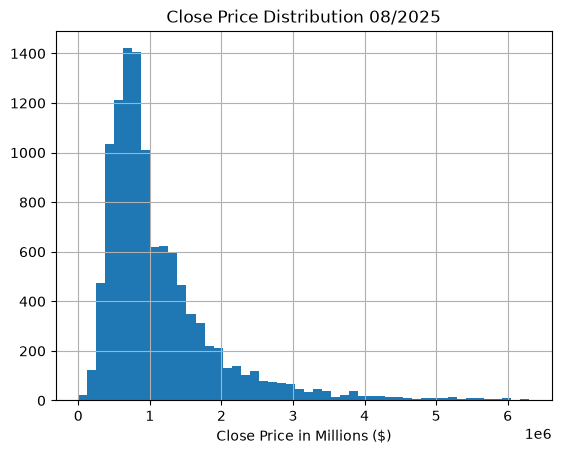

In [30]:
df = pd.read_csv(DATA_DIR / "raw/csv/CRMLSSold202508.csv")
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]
ClosePrice = df["ClosePrice"]

ClosePrice.hist(bins=50, range=(0, ClosePrice.quantile(0.99)))
plt.title("Close Price Distribution 08/2025")
plt.xlabel("Close Price in Millions ($)")
plt.show()

Closing price distribution across all reported time periods (01/2024-04/2026)

In [ ]:
all_sales = pd.concat(
    [pd.read_csv(f, usecols=["ClosePrice", "PropertyType", "PropertySubType"]).assign(month=f.stem[-6:]) for f in files], ignore_index=True,
)
all_sales = all_sales[(all_sales["PropertyType"] == "Residential") & (all_sales["PropertySubType"] == "SingleFamilyResidence")]
cap = all_sales.ClosePrice.quantile(0.99)

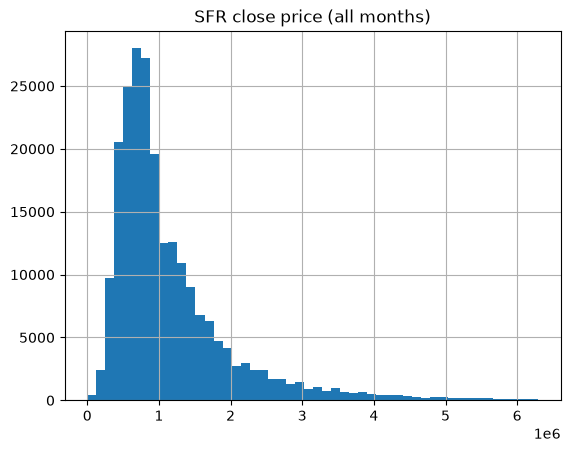

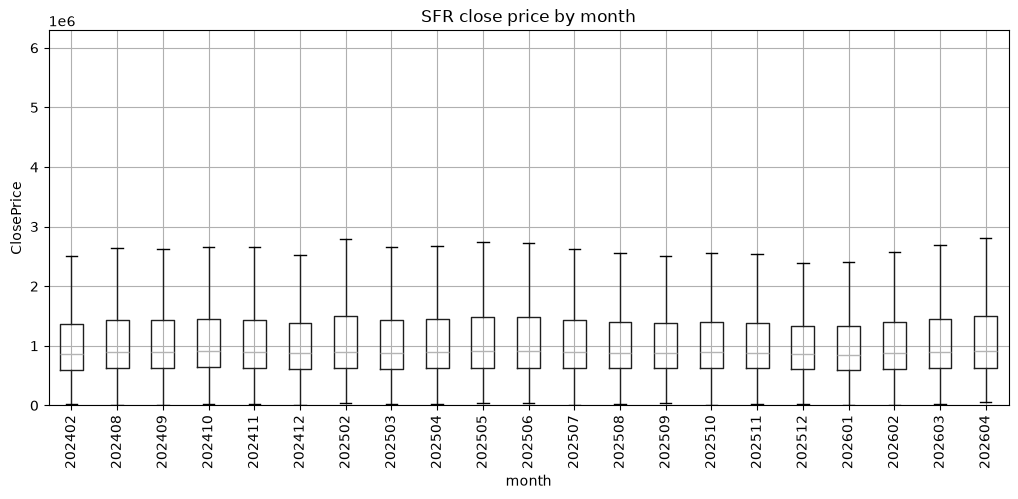

In [28]:
all_sales.ClosePrice.hist(bins=50, range=(0, cap))
plt.show()

all_sales.boxplot("ClosePrice", by="month", showfliers=False, rot=90)
plt.ylim(0, cap)
plt.show()